In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('Churn_Modelling.csv')

In [3]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [4]:
df.shape

(10000, 14)

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [ ]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [15]:
X=df.drop(columns='Exited')
y=df['Exited']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [16]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
2694,628,29,3,113146.98,2,0,1,124749.08,True,False,True
5140,626,29,4,105767.28,2,0,0,41104.82,False,False,False
2568,612,47,6,130024.87,1,1,1,45750.21,True,False,False
3671,646,52,6,111739.40,2,0,1,68367.18,True,False,False
7427,714,33,8,122017.19,1,0,0,162515.17,False,True,True


In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
print(X_train.dtypes)

RowNumber              int64
CustomerId             int64
Surname               object
CreditScore            int64
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Geography_Germany       bool
Geography_Spain         bool
Gender_Male             bool
dtype: object


In [17]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [18]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [19]:
model=Sequential()
model.add(Dense(10,activation='relu',input_dim=11))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
# THIS IS FOR MAKING HIDDEN LAYER AND OUTPUT LAYER OF ANN

c:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(loss='binary_crossentropy',optimizer='Adam')
history=model.fit(X_train_scaled,y_train,epochs=100)
# In Keras/TensorFlow, model.compile() is basically telling the neural network how it should learn.

Epoch 1/100


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 922us/step - loss: 0.3220
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3212  
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step - loss: 0.3213
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 735us/step - loss: 0.3213
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 735us/step - loss: 0.3217
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - loss: 0.3215
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 847us/step - loss: 0.3213
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 739us/step - loss: 0.3211
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step - loss: 0.3208
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step - loss: 0.3209
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step - loss: 0.3209
Epoch 12/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 747us/step - loss: 0.3205
Epoch 13/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 777us/step - loss: 0.3209
Epoch 14/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step - loss: 0.3203
Epoch 15/100
250/250 ━━━━━━

In [22]:
model.layers[0].get_weights()
# Total weights which are trained

[array([[-4.0694019e-01,  6.0234975e-02,  2.4532428e-02,  5.4308556e-02,
          1.2006116e-02,  1.9351481e-01, -5.1919505e-02,  3.8062465e-01,
         -1.0830474e-01, -8.6126819e-02],
        [-2.2921492e-01, -6.9932032e-01, -4.1518852e-01,  1.3303064e+00,
         -3.3647841e-01, -8.1003082e-01, -1.3526656e-01, -3.2386824e-01,
          1.0209848e+00,  2.8187582e-01],
        [ 2.4779107e-02,  1.1646793e-01,  7.4204758e-02,  5.3633144e-03,
         -3.9828740e-02, -7.3720798e-02, -4.8843645e-03, -3.4719008e-01,
          2.2536589e-01,  3.8486481e-02],
        [-3.1403443e-01, -9.2225753e-02, -5.2016419e-01,  1.1006902e-01,
          5.7991850e-01,  4.0356925e-01, -9.4194782e-01, -4.0885556e-01,
         -3.8827804e-01,  1.5921921e-01],
        [ 6.3007600e-03,  6.1012495e-01,  1.6884889e-01, -5.3011853e-01,
         -3.3357486e-01, -4.4504511e-01, -1.1391641e+00, -3.2707429e-01,
          2.0155500e-01,  1.3872133e+00],
        [-3.1556970e-01, -5.8406138e-01,  4.6869248e-01, -1.

In [23]:
y_log=model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 873us/step


In [24]:
y_pred=np.where(y_log>0.5,1,0)

In [25]:
from sklearn.metrics import accuracy_score
acc=accuracy_score(y_test,y_pred)
acc

0.8665

In [27]:
import matplotlib.pyplot as plt

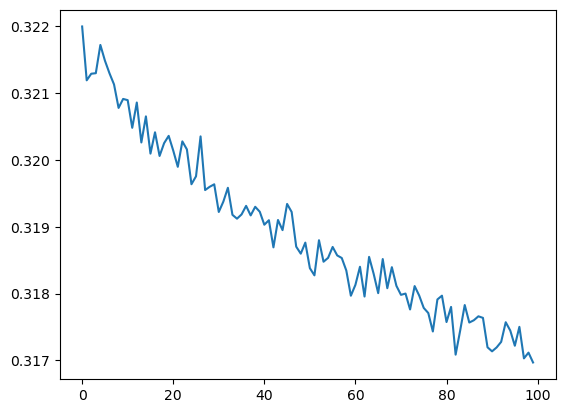

In [ ]:
plt.plot(history.history['loss'])
#You can also check the graph of accuracy